In [2]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

RWA Hamiltonian:
$$
H = K ( a^{\dagger} a^{\dagger} a a)
$$

the Heisenberg EoMs are
$$
\dot{a} = - 2iK a^{\dagger} a a 
$$
$$
\dot{aa} = - 2 K i a a - 4 i K a^{\dagger} a a a
$$
$$
\dot{a^{\dagger} a} = 0
$$

We have to make two approximations, $\langle a^{\dagger} a a  \rangle= \langle a^{\dagger} a  \rangle \langle a  \rangle$, and $ \langle a^{\dagger} a a a \rangle = \langle a^{\dagger} a \rangle \langle aa \rangle$. This gives us a closed set of equations of motion.

$$
\dot{\langle a \rangle } = - 2iK \langle a^{\dagger} a \rangle \langle a \rangle
$$
$$
\dot{\langle aa\rangle} = - 2 K i \langle a a \rangle - 4 i K \langle a^{\dagger} a \rangle \langle a a \rangle
$$
$$
\dot{\langle a^{\dagger} a\rangle} = 0
$$

We have effectively made Stark shifting and noise squeezing axis rotation the only two effects of the Kerr, because this looks  like a resonant Hamiltonian $\omega a^{\dagger} a$ with frequency $\omega = K \langle a^{\dagger} a \rangle$, plus the $ - 2 K i \langle a a \rangle$ term. However, to recover some of the other Kerr effects, we add a dephasing term to the semiclassical equations of motion (note that they must be added here because they are non-unitary).

$$
\dot{\langle a \rangle } = - 2iK \langle a^{\dagger} a \rangle \langle a \rangle - A K \langle a^{\dagger} a \rangle \langle a \rangle
$$
$$
\dot{\langle aa\rangle} = - 2 K i \langle a a \rangle - 4 i K \langle a^{\dagger} a \rangle \langle a a \rangle - B K \langle a^{\dagger} a \rangle \langle a a\rangle
$$
$$
\dot{\langle a^{\dagger} a\rangle} = 0
$$
Note that $A$ and $B$ are constants that I don't know how to calculate yet. But these two new terms have the effect of dephasing - pulling the mean value closer to zero, even if the photon number is unaffected.

For full completeness, it makes sense to add a static dephasing term with rate $\gamma_{\phi}$ and a static energy relaxation term $\kappa_{int}$. Note the factor of $1/2$ in the $\langle a \rangle$ term, since $\kappa_{int}$ is defined as an energy loss rate, but $\langle a \rangle$ is proportional to the square root of energy. ~~Likewise there's a factor of $2$ in the dephasing term of the $\langle a a \rangle$ equation, since dephasing is defined as a phase sensitive or voltage quantity.~~
$$
\dot{\langle a \rangle } = - 2iK \langle a^{\dagger} a \rangle \langle a \rangle - A K \langle a^{\dagger} a \rangle \langle a \rangle - \gamma_{\phi} \langle a \rangle - \frac{\kappa_{int}}{2} \langle a \rangle
$$
$$
\dot{\langle aa\rangle} = - 2 K i \langle a a \rangle - 4 i K \langle a^{\dagger} a \rangle \langle a a \rangle - B K \langle a^{\dagger} a \rangle \langle a a\rangle - 2 \gamma_{\phi} \langle a a \rangle - \kappa_{int} \langle a a \rangle
$$
$$
\dot{\langle a^{\dagger} a \rangle} = -\kappa_{int} \langle  a^{\dagger} a \rangle
$$

Comparison with qutip seems to suggest a factor of 1/2 in the $a$ dephasing term and 2 in the $aa$ dephasing term.

In [3]:
disp = 3

wb = 0.001*2*np.pi
K = 0.003*2*np.pi
kappa_int = 0.000*2*np.pi

gamma_phi = 0.000*2*np.pi

A = 1
B = 2

In [4]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('wa', wb, is_excitation=True)
sim.add_param('sqrtka', np.sqrt(kappa_int))
sim.add_param('gamma_phi', gamma_phi)
sim.add_param('K', K)
sim.add_param('A', A)
sim.add_param('B', B)
sim.add_param('IC', disp)

sim.add_EOM('a', '-2j*K*na*a - A*K*na*a - gamma_phi*a/2 - (sqrtka**2)/2*a',IC_str='IC')
sim.add_EOM('aa', '-2j*K*aa - 4j*K*na*aa - B*K*na*aa - gamma_phi*aa*2 - (sqrtka**2)*aa', IC_str='IC**2')
sim.add_EOM('na', '-(sqrtka**2)*na',IC_str='abs(IC)**2')

sim.set_solve_type('all')

sim.specify_time(t_f=200, pts=20001)

sim.validate()



Recent change to specify_time(), check implementation
Simulation validation success!


Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


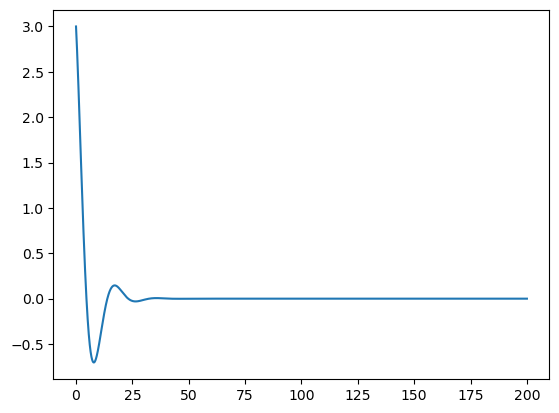

In [5]:
x, t = sim.quick_trace()


plt.plot(t, x[0,:])
plt.show()

In [6]:
b = x[0,:]+1j*x[1,:]
bb = x[2,:]+1j*x[3,:]
nb = x[4,:]+1j*x[5,:]

In [7]:
def plot_Qfunc(a, aa, na, ax=None, plot_arg=None):

    if ax == None:
        ax = plt.gca()
    
    ad = np.conjugate(a)
    adad = np.conjugate(aa)
    sxx = 1/2 + 1/2*( (aa - a*a) + 2*(na - ad*a) + (adad - ad*ad))
    syy = 1/2 - 1/2*( (aa - a*a) - 2*(na - ad*a) + (adad - ad*ad))
    sxy = np.imag(1/2*((aa - a*a) - (adad - ad*ad)))
    covar =  np.real(np.array([[sxx, sxy], [sxy, syy]]))

    print(covar)
    print(' ')

    phi = np.linspace(0, 2*np.pi, 101)
    
    print(np.argsort(np.linalg.eig(covar)[0]))

    order = np.argsort(np.linalg.eig(covar)[0])
    major_idx = order[1]
    minor_idx = order[0]
    
    theta = -np.angle(np.linalg.eig(covar)[1][:,1][minor_idx]+1j*np.linalg.eig(covar)[1][:,1][major_idx])
    Smajor = np.sort(np.linalg.eig(covar)[0])[major_idx]
    Sminor = np.sort(np.linalg.eig(covar)[0])[minor_idx]
    
    x1 = np.sqrt(Smajor)*np.cos(phi)*2
    y1 = np.sqrt(Sminor)*np.sin(phi)*2
    
    x2 = x1*np.cos(theta) + y1*np.sin(theta) + np.real(a)
    y2 = -x1*np.sin(theta) + y1*np.cos(theta) + np.imag(a)

    if plot_arg == None:
        ax.plot(x2,y2)
    else:
        ax.plot(x2,y2,plot_arg)
    # ax.xlim([-7,7])
    # ax.ylim([-7,7])
    # plt.gca().set_aspect('equal')
    # plt.grid()
    # plt.show()


In [8]:
# i = 0
# j = -1
# plot_Qfunc(b[i,j], bb[i,j], nb[i,j])
# plt.xlim([-7,7])
# plt.ylim([-7,7])
# plt.gca().set_aspect('equal')
# plt.grid()
# plt.show()

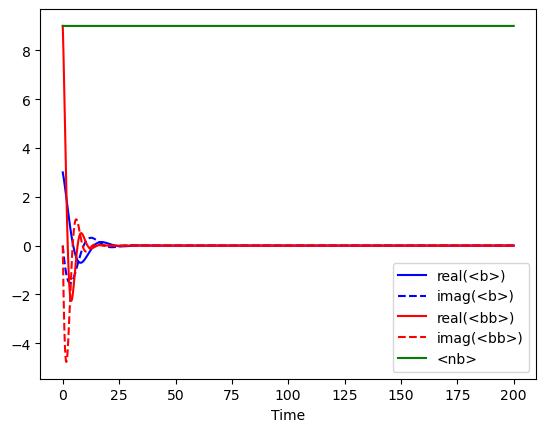

In [9]:
tlist = np.unique(t)
plt.plot(tlist, np.real(b),'b-',label='real(<b>)')
plt.plot(tlist, np.imag(b),'b--',label='imag(<b>)')
plt.plot(tlist, np.real(bb),'r-',label='real(<bb>)')
plt.plot(tlist, np.imag(bb),'r--',label='imag(<bb>)')
plt.plot(tlist, np.real(nb),'g',label='<nb>')
plt.legend()
plt.xlabel('Time')
plt.show()

# QuTiP version

In [10]:
from base64 import b64encode

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation
from qutip import (about, basis, coherent, destroy, displace, expect, mesolve,
                   num, plot_fock_distribution, plot_wigner, squeeze, variance, Options)

%matplotlib inline

In [11]:
N = 30

# operators
a = destroy(N)
n = num(N)
x = (a + a.dag()) / np.sqrt(2)
p = -1j * (a - a.dag()) / np.sqrt(2)

H = K*a.dag()*a.dag()*a*a

c_ops = [np.sqrt(gamma_phi)*a.dag()*a, np.sqrt(kappa_int)*a]

In [12]:
def plot_expect_with_variance(N, op_list, op_title, states):
    """
    Plot the expectation value of an operator (list of operators)
    with an envelope that describes the operators variance.
    """

    fig, axes = plt.subplots(1, len(op_list), figsize=(14, 3))

    for idx, op in enumerate(op_list):

        e_op = expect(op, states)
        v_op = variance(op, states)

        axes[idx].fill_between(
            tlist, e_op - np.sqrt(v_op), e_op + np.sqrt(v_op), color="green",
            alpha=0.5)
        axes[idx].plot(tlist, e_op, label="expectation")
        axes[idx].set_xlabel("Time")
        axes[idx].set_title(op_title[idx])

    return fig, axes

C:\Users\boris\anaconda3\envs\fullconda\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
C:\Users\boris\anaconda3\envs\fullconda\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\boris\anaconda3\envs\fullconda\Lib\site-packages\numpy\ma\core.py:2881: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\boris\anaconda3\envs\fullconda\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


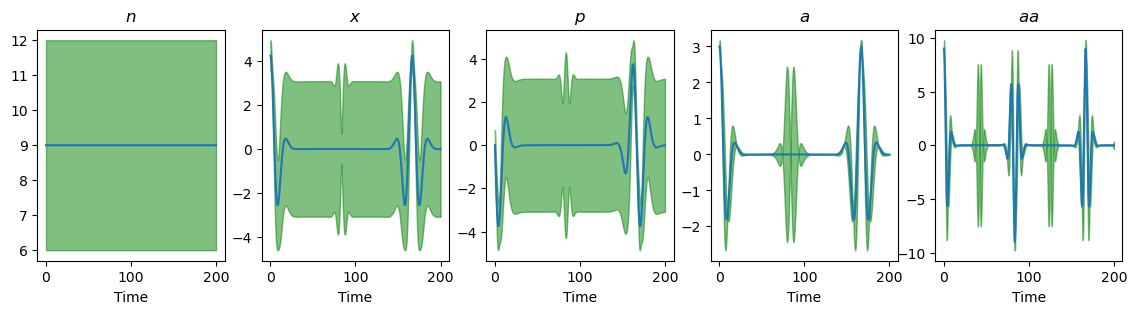

In [13]:
psi0 = coherent(N, disp)

result = mesolve(H, psi0, t, c_ops, [], options={'nsteps': 100000})

plot_expect_with_variance(N, [n, x, p, a, a*a], [r"$n$", r"$x$", r"$p$",  r"$a$",  r"$aa$"],
                          result.states);
plt.show()

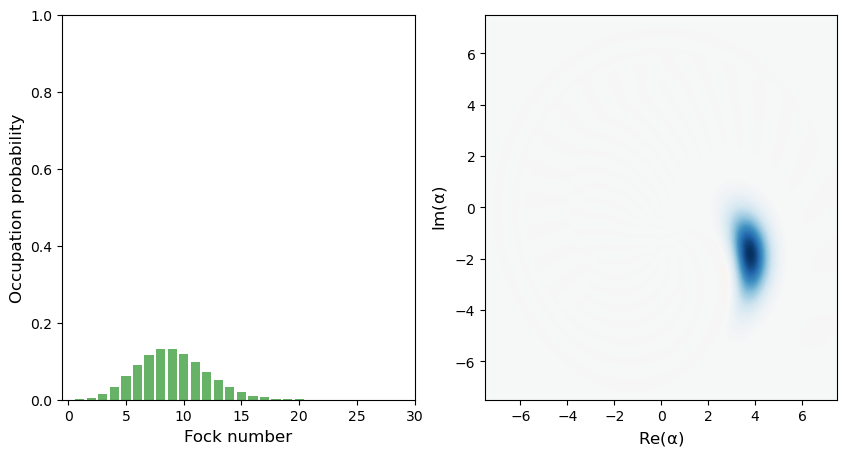

In [14]:
# i = 0

# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# axes[0].cla()
# plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
# plot_wigner(result.states[i], fig=fig, ax=axes[1])
# plt.show()

i = 16800

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].cla()
plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
plot_wigner(result.states[i], fig=fig, ax=axes[1])
plt.show()

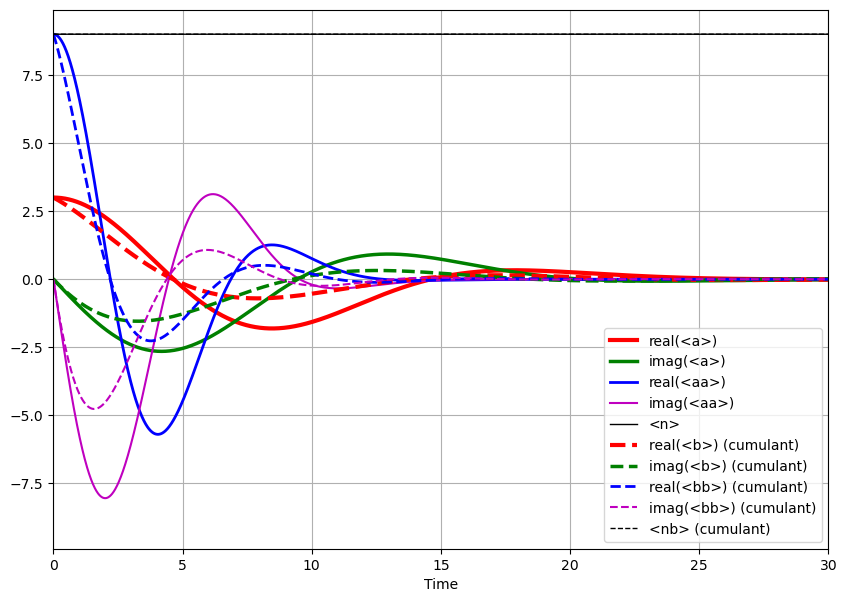

In [19]:
plt.figure(figsize=(10,7))
plt.plot(t,np.real(expect(a, result.states)),'r-',label='real(<a>)',linewidth=3)
plt.plot(t,np.imag(expect(a, result.states)),'g-',label='imag(<a>)',linewidth=2.5)
plt.plot(t,np.real(expect(a*a, result.states)),'b-',label='real(<aa>)',linewidth=2)
plt.plot(t,np.imag(expect(a*a, result.states)),'m-',label='imag(<aa>)',linewidth=1.5)
plt.plot(t,expect(a.dag()*a, result.states),'k-',label='<n>',linewidth=1)

plt.plot(t,np.real(b),'r--',label='real(<b>) (cumulant)',linewidth=3)
plt.plot(t,np.imag(b),'g--',label='imag(<b>) (cumulant)',linewidth=2.5)
plt.plot(t,np.real(bb),'b--',label='real(<bb>) (cumulant)',linewidth=2)
plt.plot(t,np.imag(bb),'m--',label='imag(<bb>) (cumulant)',linewidth=1.5)
plt.plot(t,np.real(nb),'k--',label='<nb> (cumulant)',linewidth=1)
plt.xlim([0,30])
# plt.ylim([-0.1,0.1])
plt.legend()
plt.grid()
plt.xlabel('Time')
plt.show()

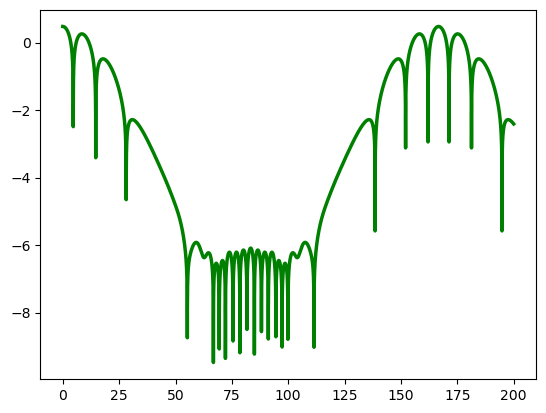

In [20]:
plt.plot(t,np.log10(np.abs(np.real(expect(a, result.states)))),'g-',label='imag(<a>)',linewidth=2.5)
plt.show()

# Overlay comparison

[[9.49999540e+00 1.08535791e-05]
 [1.08535791e-05 9.49998823e+00]]
 
[1 0]


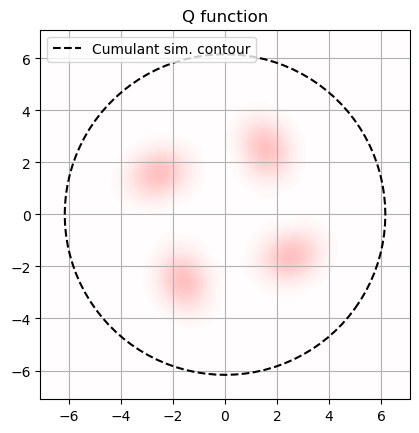

[[9.49999540e+00 1.08535791e-05]
 [1.08535791e-05 9.49998823e+00]]
 
[1 0]


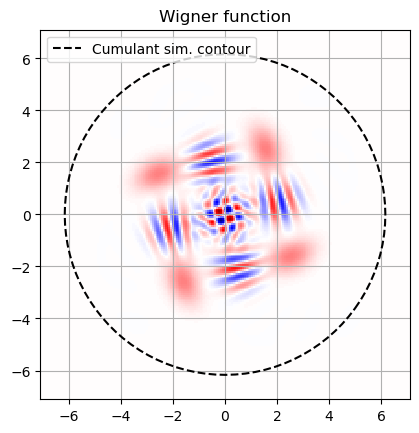

In [17]:
from qutip.wigner import qfunc, wigner

'''
TODO: why do I need the 1/sqrt(2)
'''

i = 4100

xvec = np.linspace(-10,10,201)

plot_Qfunc(b[i], bb[i], nb[i], plot_arg='k--')
plt.legend(['Cumulant sim. contour'],loc='upper left')
plt.pcolor(xvec/np.sqrt(2), xvec/np.sqrt(2), qfunc(result.states[i], xvec, xvec),cmap='seismic',clim=([-1/np.pi,1/np.pi]))
plt.gca().set_aspect('equal')
plt.grid()
plt.title('Q function')

plt.show()

plot_Qfunc(b[i], bb[i], nb[i], plot_arg='k--')
plt.legend(['Cumulant sim. contour'],loc='upper left')
plt.pcolor(xvec/np.sqrt(2), xvec/np.sqrt(2), wigner(result.states[i], xvec, xvec),cmap='seismic',clim=([-1/np.pi,1/np.pi]))
plt.gca().set_aspect('equal')
plt.grid()
plt.title('Wigner function')

plt.show()

# Some confusions

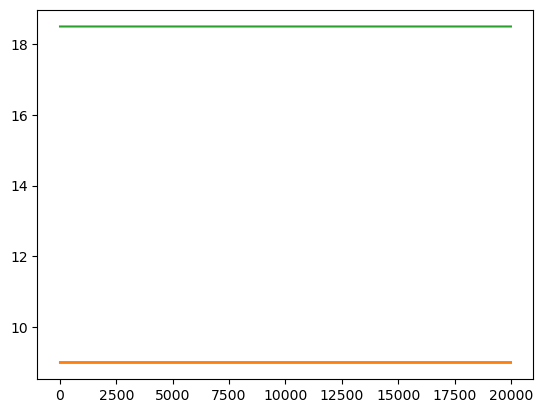

In [18]:
# following Girvin's cqed, they should all be the same, but they are not
plt.plot(expect(a.dag()*a, result.states))
plt.plot(expect(n, result.states))
plt.plot(expect(x*x+p*p-0.5, result.states))
plt.show()